In [7]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/operator_experiment_33'

data_df = pd.read_csv(os.path.join(dir, 'results.csv')).drop(columns=['Unnamed: 0'])

data_df['operator'] = data_df['operator'].astype(int)

data_df['beamforming'] = data_df['operator'] != 1

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['pca'] = data_df['use_pca'].apply(lambda x: 'With PCA' if x == 1 else 'Without PCA')

result_df = data_df
result_df['complexity'] = result_df['complexity'] / 1000

result_df.sort_values('use_pca', ascending=True, inplace=True)

result_df

,operator,n_clusters,use_pca,runtime,error,complexity,beamforming,pca
605475,88,10.0,0.0,2.546641,5.193889,86.688,True,Without PCA
403646,10,10.0,0.0,4.863156,0.263929,387.600,True,Without PCA
403647,10,10.0,0.0,4.863156,0.016474,387.600,True,Without PCA
403648,10,10.0,0.0,4.863156,0.613562,387.600,True,Without PCA
403649,10,10.0,0.0,4.863156,3.915011,387.600,True,Without PCA
...,...,...,...,...,...,...,...,...
201826,50,10.0,1.0,1.954190,0.594071,16.035,True,With PCA
201827,50,10.0,1.0,1.954190,0.362691,16.035,True,With PCA
201828,50,10.0,1.0,1.954190,1.245892,16.035,True,With PCA
201812,50,10.0,1.0,1.954190,7.889496,16.035,True,With PCA


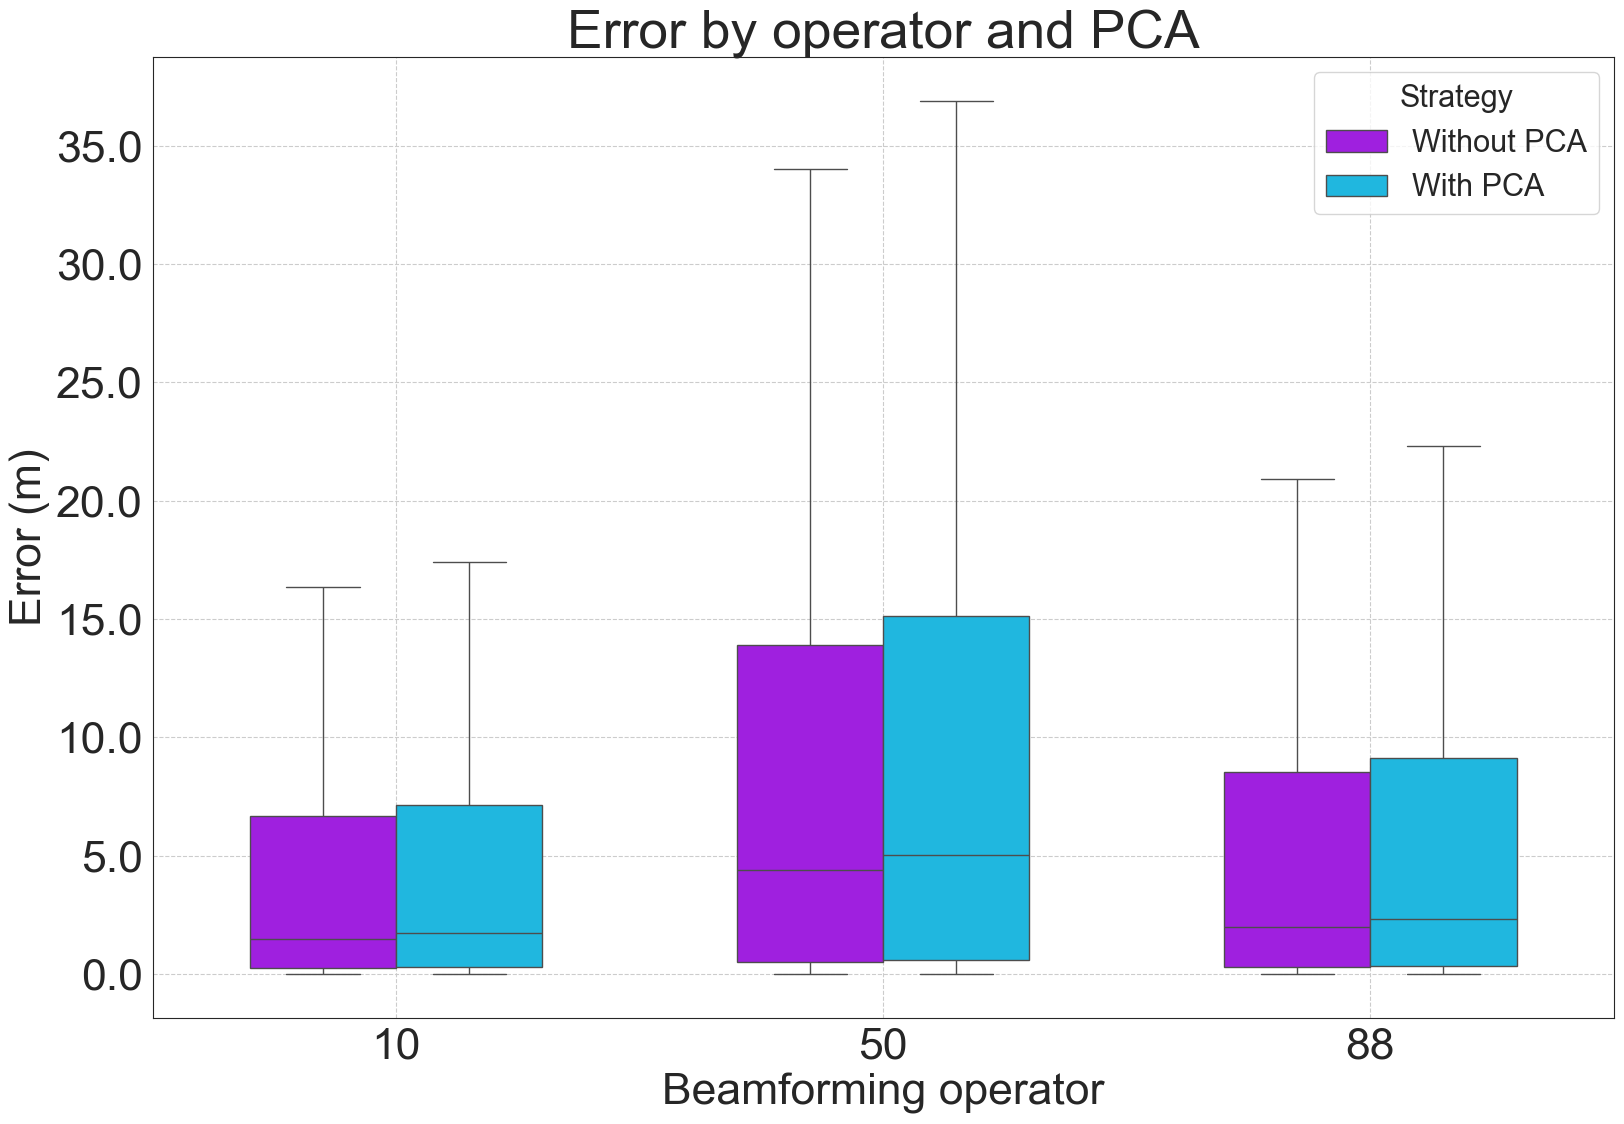

In [23]:

from scripts.utils import get_config
import seaborn as sns
import matplotlib.pyplot as plt

palette = {'Without PCA': '#AA00FF', 'With PCA': '#00CAFF'}


def plot_pca_experiment(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    sns.boxplot(x='operator', y='error', hue='pca', palette=palette, data=data_df, width=0.6, showfliers=False)

    # Add labels and title
    plt.xlabel('Beamforming operator')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    # Improve the legend
    plt.legend(title='Strategy', fontsize='22', loc='upper right', title_fontsize=22)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_pca_experiment(result_df[result_df['operator'] != 1])


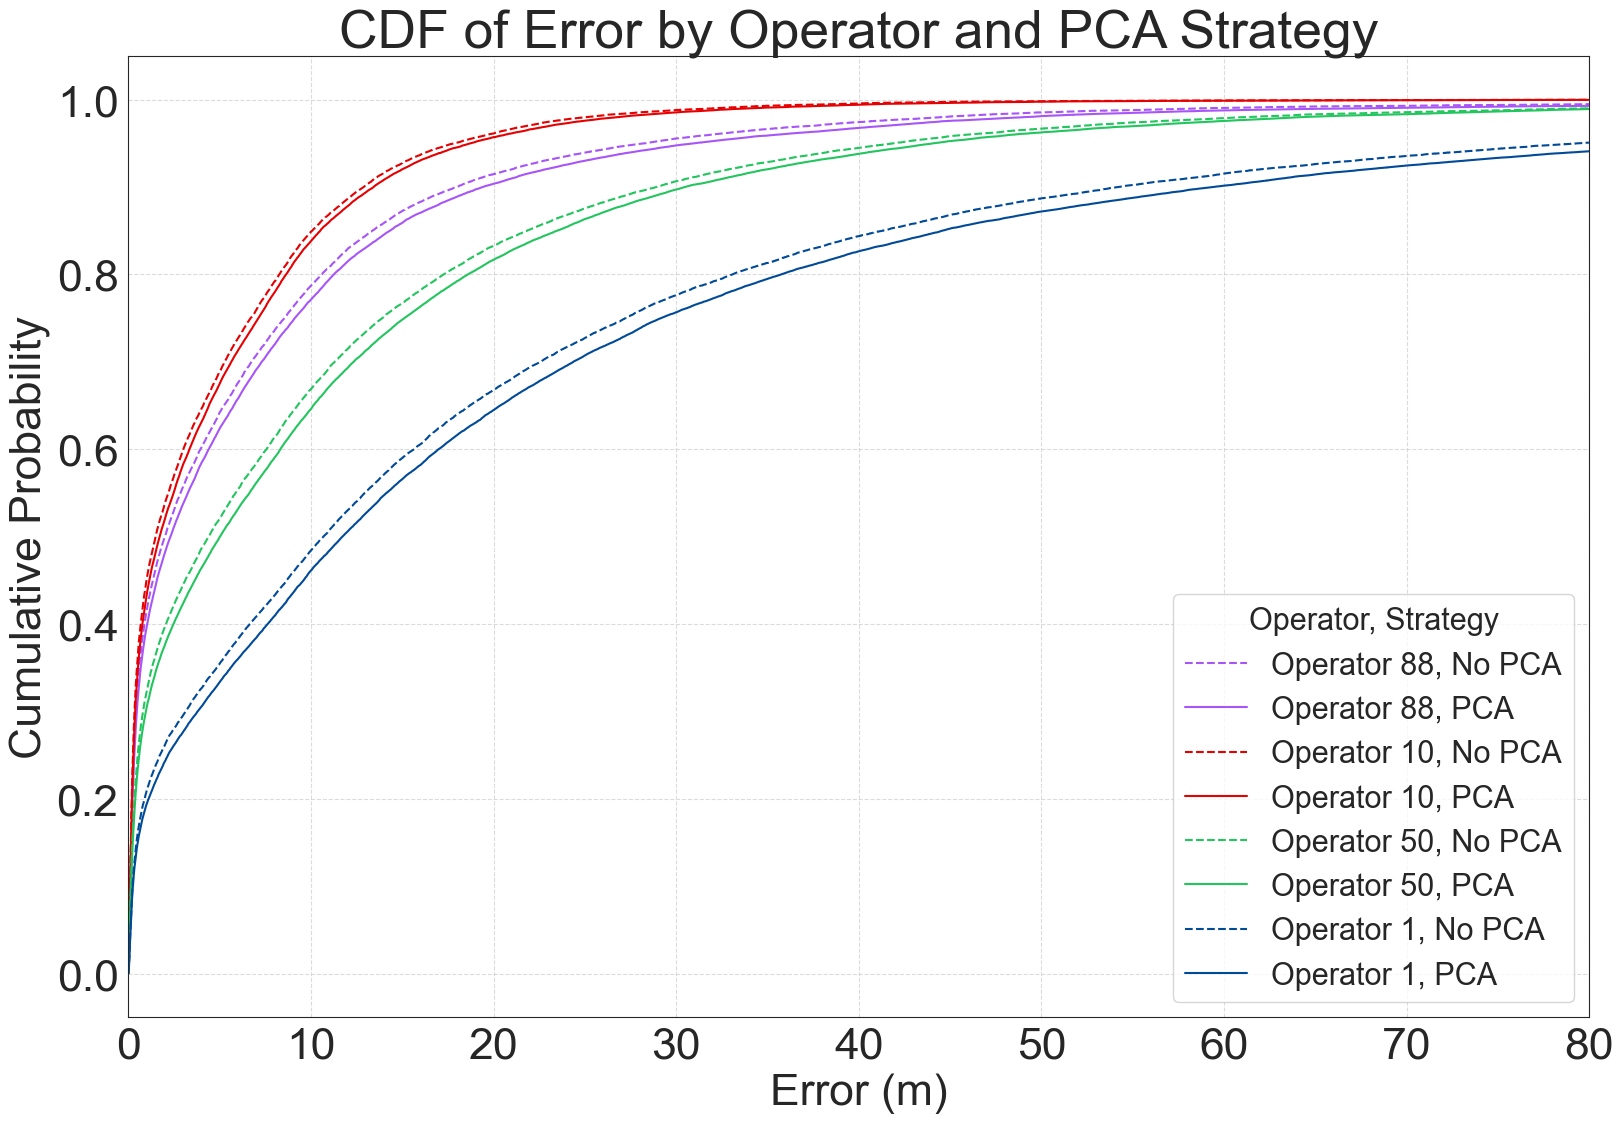

operator  use_pca
1         0.0        20.813654
          1.0        22.656119
10        0.0         4.618004
          1.0         4.915597
50        0.0        10.666306
          1.0        11.441737
88        0.0         6.921477
          1.0         7.656781
Name: error, dtype: float64

In [18]:
import numpy as np


def plot_pca_experiment_cdf(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    # Get unique combinations of operator and pca
    operators = data_df['operator'].unique()
    pca_strategies = data_df['use_pca'].unique()
    beamforming_strategies = data_df['beamforming'].unique()

    # Create CDF plot
    for op in operators:
        for pca in pca_strategies:
            # Filter data for this operator and PCA strategy
            subset = data_df[(data_df['operator'] == op) & (data_df['use_pca'] == pca)]
            if len(subset) == 0:
                continue

            # Sort the error values
            sorted_errors = np.sort(subset['error'].values)
            # Calculate the CDF (y-axis values)
            y_values = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

            color = color_map[str(op)]

            # Different line styles for different PCA strategies
            linestyle = '-' if pca == True else '--'

            # Plot the CDF
            label = f"Operator {op}, {'PCA' if pca else 'No PCA'}"
            plt.plot(sorted_errors, y_values, label=label, linestyle=linestyle, color=color)

    # Add labels and title
    plt.xlabel('Error (m)')
    plt.ylabel('Cumulative Probability')
    plt.title('CDF of Error by Operator and PCA Strategy')

    # Improve the legend
    plt.legend(title='Operator, Strategy', fontsize='22', loc='lower right', title_fontsize=22)

    # Add grid
    plt.grid(linestyle='--', alpha=0.7)

    # Set x-axis limit similar to your boxplot
    plt.xlim((0, 80))

    # Show the plot
    plt.tight_layout()
    plt.show()


# Call the function with your data
plot_pca_experiment_cdf(result_df)
result_df.groupby(["operator", "use_pca"])['error'].mean()

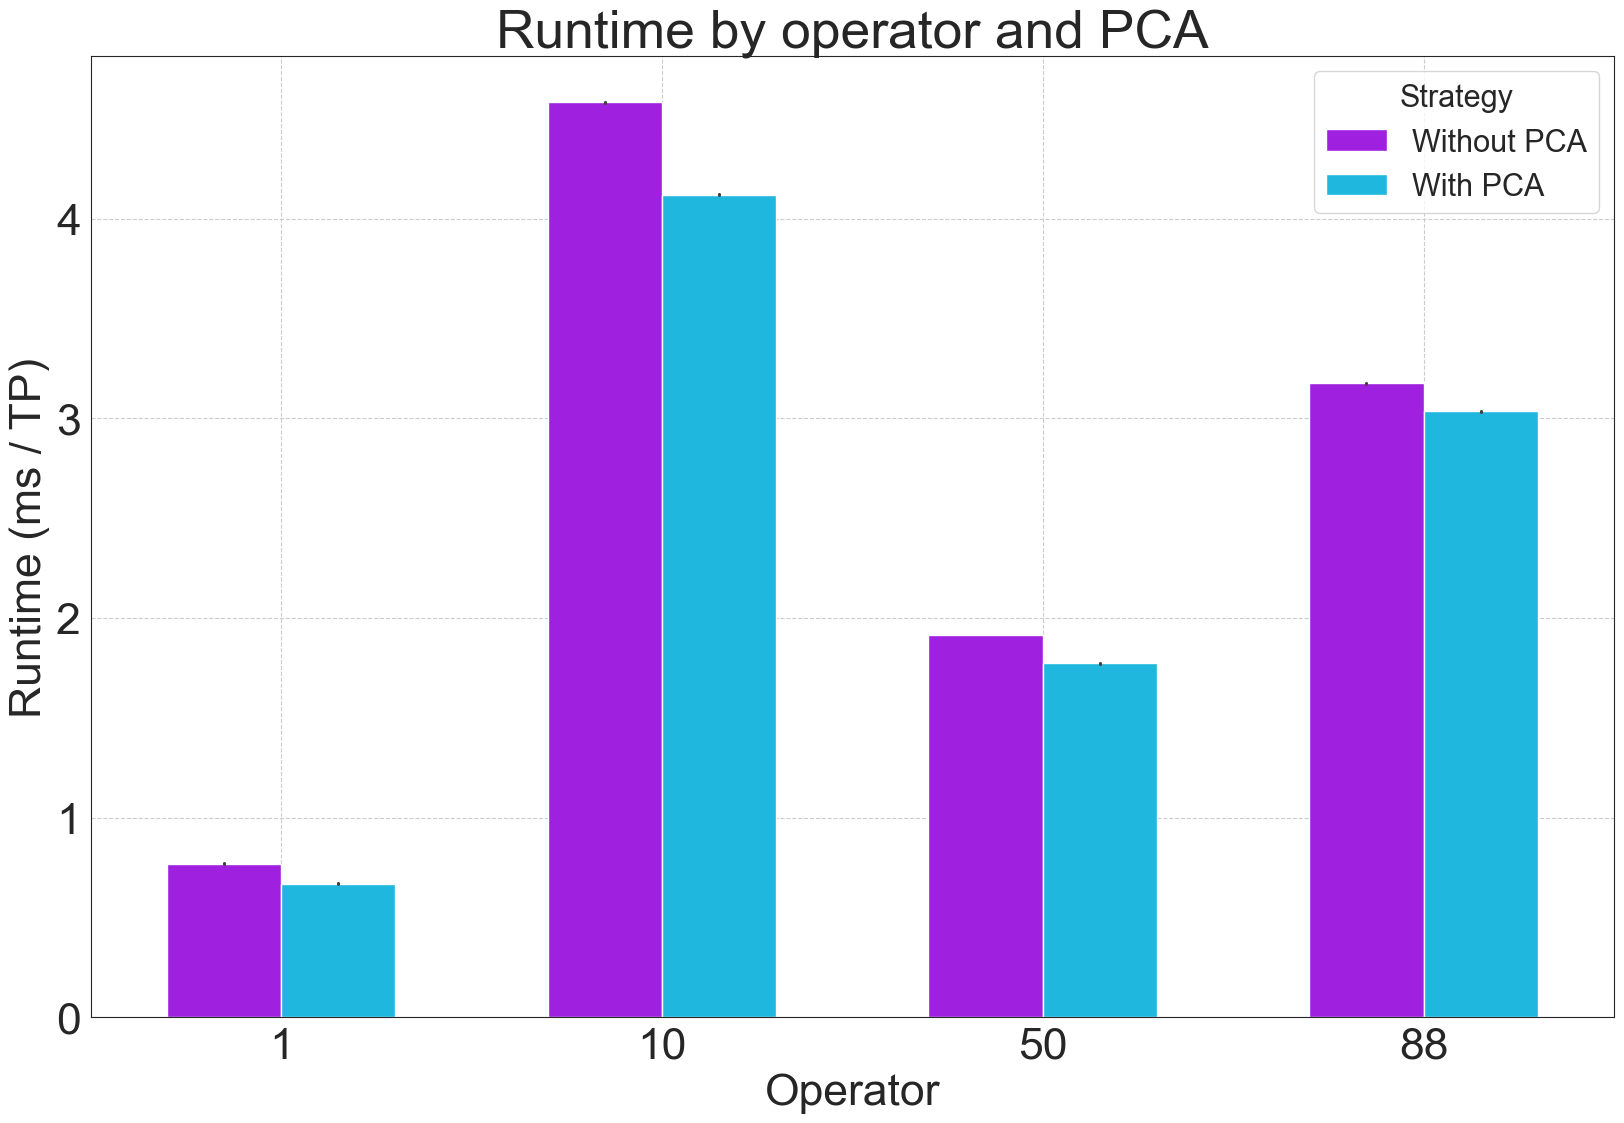

In [4]:
def plot_pca_experiment_runtime(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    sns.barplot(x='operator', y='runtime', hue='pca', palette=palette, data=data_df, width=0.6)

    # Add labels and title
    plt.xlabel('Operator')
    plt.ylabel('Runtime (ms / TP)')
    plt.title('Runtime by operator and PCA')

    # Improve the legend
    plt.legend(title='Strategy', fontsize='22', loc='upper right', title_fontsize=22)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_pca_experiment_runtime(result_df)

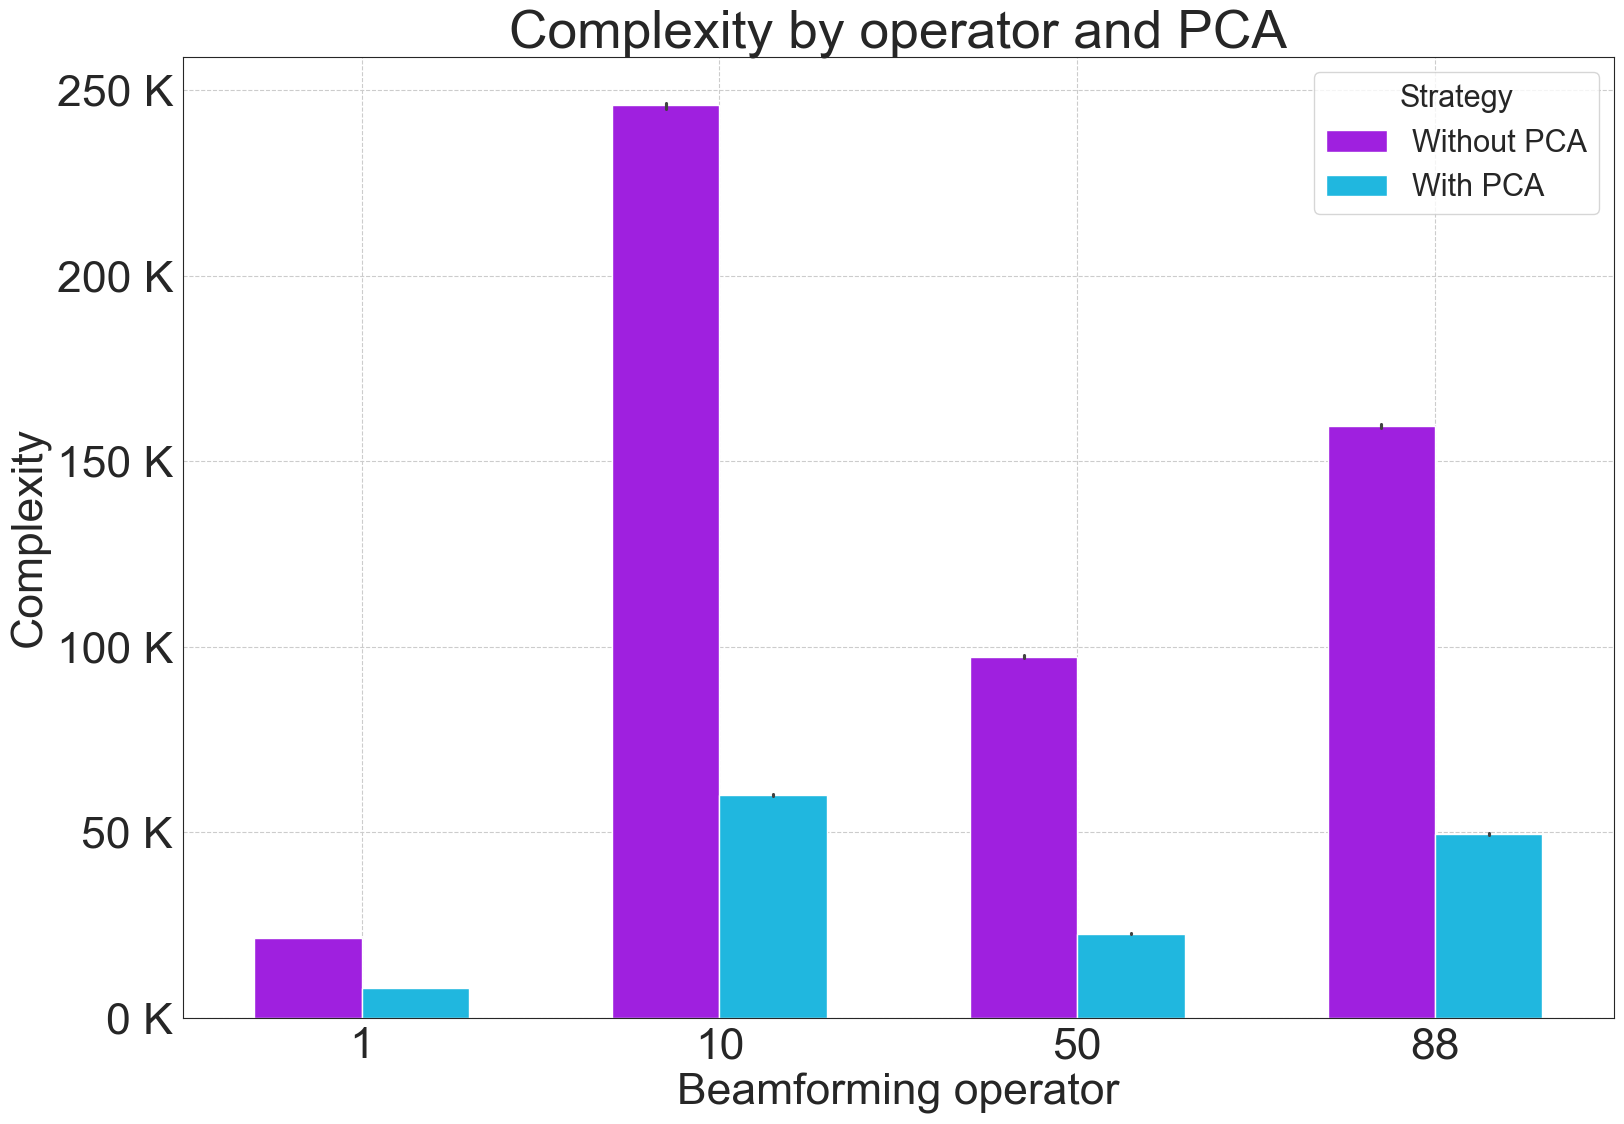

In [5]:
def plot_pca_experiment_complexity(data_df: pd.DataFrame):
    color_map = get_config('color_map.json', 'operatorId')

    plt.rcParams.update({"font.size": 32})
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    sns.barplot(x='operator', y='complexity', hue='pca', palette=palette, data=data_df, width=0.6)

    # Add labels and title
    plt.xlabel('Beamforming operator')
    plt.ylabel('Complexity')
    plt.title('Complexity by operator and PCA')

    # Improve the legend
    plt.legend(title='Strategy', fontsize='22', loc='upper right', title_fontsize=22)

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f K'))

    # Show the plot
    plt.tight_layout()
    plt.show()


plot_pca_experiment_complexity(result_df)